In [1]:
import json
import pandas as pd
import numpy as np

In [2]:
# 1. Load the JSON file
file_path = "/home/varrel/image_model_dict/swinb_multilabel_inference_metrics_final.json"

try:
    with open(file_path, "r") as f:
        data = json.load(f)
    print(f"Successfully loaded metrics for {len(data)} datasets.")
except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
    # Create dummy data for demonstration if file is missing
    data = {}

Successfully loaded metrics for 7 datasets.


In [3]:
print("\n" + "="*40)
print("       MACRO METRICS (Per Dataset)")
print("="*40)

macro_rows = []

for ds_name, metrics in data.items():
    # Extract Macro stats
    # Note: Keys might vary slightly based on your exact save structure, 
    # but based on your previous code, they should be under 'macro'
    if 'macro' in metrics:
        m = metrics['macro']
        row = {
            'Dataset': ds_name,
            'Macro F1': f"{m.get('f1_mean', 0):.4f} ± {m.get('f1_std', 0):.4f}",
            'Macro AUC': f"{m.get('rocauc_mean', 0):.4f} ± {m.get('rocauc_std', 0):.4f}",
            'Macro MCC': f"{m.get('mcc_mean', 0):.4f} ± {m.get('mcc_std', 0):.4f}",
            # Add others if needed (Accuracy, Precision, Recall)
        }
        macro_rows.append(row)

df_macro = pd.DataFrame(macro_rows)

# Display styled dataframe
if not df_macro.empty:
    display(df_macro.style.set_caption("Macro Performance Summary").hide(axis="index"))
else:
    print("No macro metrics found in JSON.")


# ==========================================
# 3. PER-PATHOLOGY METRICS REPORT
# ==========================================
print("\n" + "="*40)
print("   PER-PATHOLOGY METRICS (Detailed)")
print("="*40)

# We'll create a Multi-Index DataFrame for better organization
# Index: [Dataset, Pathology]
# Columns: [F1, AUC, MCC]

pathology_rows = []

for ds_name, metrics in data.items():
    if 'per_class' in metrics:
        for pathology, scores in metrics['per_class'].items():
            
            # Format: "Mean ± Std"
            f1_str = f"{scores.get('f1_mean', 0):.4f} ± {scores.get('f1_std', 0):.4f}"
            auc_str = f"{scores.get('rocauc_mean', 0):.4f} ± {scores.get('rocauc_std', 0):.4f}"
            mcc_str = f"{scores.get('mcc_mean', 0):.4f} ± {scores.get('mcc_std', 0):.4f}"
            
            # Helper to get raw float for sorting (optional)
            f1_val = scores.get('f1_mean', 0)
            
            pathology_rows.append({
                'Dataset': ds_name,
                'Pathology': pathology,
                'F1 Score': f1_str,
                'AUC-ROC': auc_str,
                'MCC': mcc_str,
                '_sort_val': f1_val # Hidden column for sorting
            })

df_pathology = pd.DataFrame(pathology_rows)

if not df_pathology.empty:
    # Pivot to make it readable: 
    # Row = Pathology, Column = Dataset (Metric) is too wide. 
    # Better: Group by Dataset or just show long format.
    
    # Option A: Long Format (Cleanest for reading list)
    df_pathology_sorted = df_pathology.sort_values(by=['Dataset', 'Pathology'])
    df_clean = df_pathology_sorted.drop(columns=['_sort_val'])
    
    display(df_clean.style.set_caption("Per-Pathology Performance"))

    # Option B: Pivot Table for F1 Scores (Comparison Matrix)
    # Allows you to see Pneumothorax F1 across all datasets side-by-side
    print("\n--- F1 Score Comparison Matrix ---")
    
    # Create simple dataframe for Pivot
    df_pivot_data = []
    for row in pathology_rows:
        # Extract just the mean score string
        df_pivot_data.append({
            'Dataset': row['Dataset'], 
            'Pathology': row['Pathology'], 
            'F1': row['F1 Score']
        })
    
    df_p = pd.DataFrame(df_pivot_data)
    f1_pivot = df_p.pivot(index='Pathology', columns='Dataset', values='F1')
    display(f1_pivot)

else:
    print("No per-class metrics found.")


       MACRO METRICS (Per Dataset)


Dataset,Macro F1,Macro AUC,Macro MCC
NIH,0.2390 ± 0.0056,0.8112 ± 0.0034,0.2044 ± 0.0060
OpenI,0.1837 ± 0.0544,0.7601 ± 0.0243,0.1936 ± 0.0656
CheXpert,0.8443 ± 0.0016,0.9008 ± 0.0014,0.6212 ± 0.0034
MIMIC,0.4290 ± 0.0026,0.8191 ± 0.0016,0.3301 ± 0.0031
PC,0.2967 ± 0.0068,0.8713 ± 0.0032,0.2767 ± 0.0083
VinDR,0.2386 ± 0.0134,nan ± nan,0.2185 ± 0.0139
Merged,0.7248 ± 0.0016,0.9134 ± 0.0007,0.6320 ± 0.0019



   PER-PATHOLOGY METRICS (Detailed)


,Dataset,Pathology,F1 Score,AUC-ROC,MCC
16,CheXpert,Atelectasis,0.8588 ± 0.0023,0.9008 ± 0.0022,0.6289 ± 0.0054
15,CheXpert,Cardiomegaly,0.8529 ± 0.0024,0.8939 ± 0.0024,0.6126 ± 0.0059
13,CheXpert,Consolidation,0.8304 ± 0.0029,0.8969 ± 0.0023,0.6277 ± 0.0056
12,CheXpert,Edema,0.7974 ± 0.0031,0.8931 ± 0.0023,0.5968 ± 0.0055
17,CheXpert,Lung Opacity,0.9102 ± 0.0017,0.9314 ± 0.0019,0.6459 ± 0.0063
14,CheXpert,Pleural Effusion,0.8160 ± 0.0030,0.8884 ± 0.0023,0.6154 ± 0.0056
22,MIMIC,Atelectasis,0.4863 ± 0.0056,0.7974 ± 0.0031,0.3495 ± 0.0067
21,MIMIC,Cardiomegaly,0.4403 ± 0.0064,0.7970 ± 0.0031,0.3218 ± 0.0074
19,MIMIC,Consolidation,0.0280 ± 0.0063,0.7944 ± 0.0054,0.0190 ± 0.0085
18,MIMIC,Edema,0.4888 ± 0.0080,0.8871 ± 0.0027,0.4252 ± 0.0087



--- F1 Score Comparison Matrix ---


Dataset,CheXpert,MIMIC,Merged,NIH,OpenI,PC,VinDR
Pathology,,,,,,,
Atelectasis,0.8588 ± 0.0023,0.4863 ± 0.0056,0.7001 ± 0.0025,0.2991 ± 0.0148,0.1082 ± 0.0498,0.1810 ± 0.0146,0.0000 ± 0.0000
Cardiomegaly,0.8529 ± 0.0024,0.4403 ± 0.0064,0.7144 ± 0.0027,0.2396 ± 0.0266,0.2520 ± 0.0648,0.4996 ± 0.0136,0.5465 ± 0.0286
Consolidation,0.8304 ± 0.0029,0.0280 ± 0.0063,0.7574 ± 0.0031,0.0000 ± 0.0000,0.2486 ± 0.2294,0.0000 ± 0.0000,0.0000 ± 0.0000
Edema,0.7974 ± 0.0031,0.4888 ± 0.0080,0.7153 ± 0.0032,0.0000 ± 0.0000,0.0914 ± 0.0894,0.0643 ± 0.0279,0.0000 ± 0.0000
Lung Opacity,0.9102 ± 0.0017,0.4474 ± 0.0056,0.7221 ± 0.0023,0.3715 ± 0.0099,0.1819 ± 0.0405,0.4430 ± 0.0131,0.3263 ± 0.0531
Pleural Effusion,0.8160 ± 0.0030,0.6833 ± 0.0045,0.7397 ± 0.0025,0.5240 ± 0.0118,0.2198 ± 0.0828,0.5925 ± 0.0164,0.5588 ± 0.0535


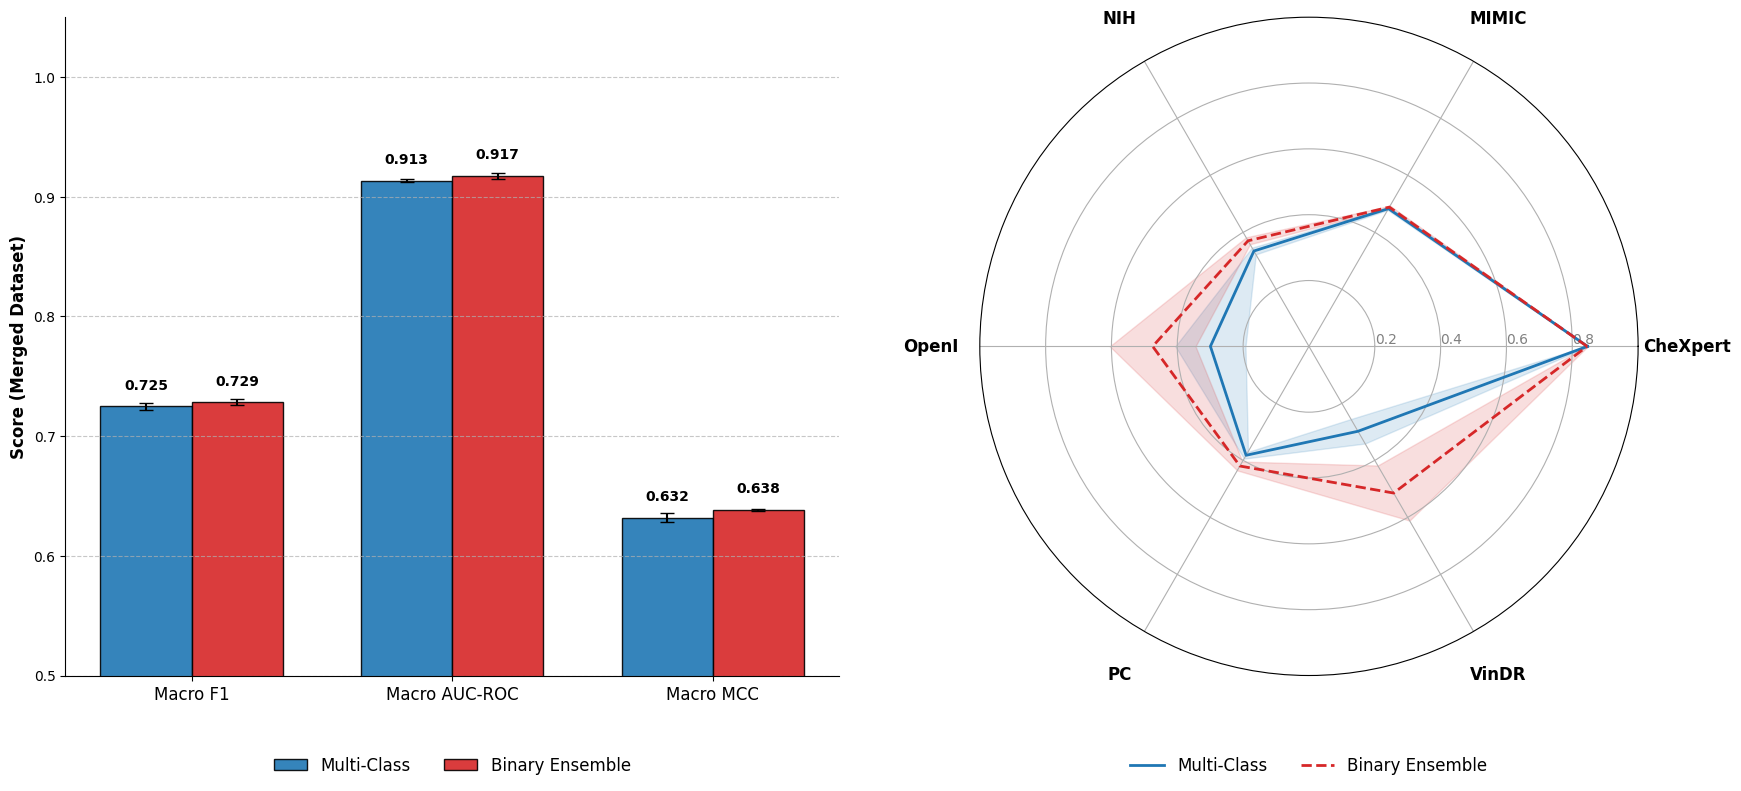

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def plot_combined_comparison():
    # --- DATA PREP ---
    # 1. Bar Chart Data
    metrics = ['Macro F1', 'Macro AUC-ROC', 'Macro MCC']
    ml_bar_scores = [0.7248, 0.9134, 0.6320]
    bin_bar_scores = [0.7285, 0.9174, 0.6385]
    
    # --- PLUG YOUR 95% CI VALUES HERE ---
    # Format: [F1_err, AUC_err, MCC_err]
    ml_bar_err = [0.003136, 0.001372, 0.003724] 
    bin_bar_err = [0.002216, 0.002768, 0.000941]

    # 2. Radar Chart Data
    datasets = ['CheXpert', 'MIMIC', 'NIH', 'OpenI', 'PC', 'VinDR']
    ml_radar_scores = [0.8461, 0.4832, 0.3345, 0.2994, 0.3821, 0.2979]
    bin_radar_scores = [0.8451, 0.4885, 0.3703, 0.4748, 0.4198, 0.5146]
    
    # --- PLUG YOUR RADAR 95% CI VALUES HERE ---
    # List of errors for each of the 6 datasets
    ml_radar_err = [0.003136, 0.004704, 0.01176, 0.10662, 0.01176, 0.042924]
    bin_radar_err = [0.002128, 0.004675, 0.01205, 0.13025, 0.01553, 0.09655]

    # --- SETUP FIGURE ---
    fig = plt.figure(figsize=(18, 8))
    
    # ==========================================
    # SUBPLOT 1: BAR CHART (Standard Projection)
    # ==========================================
    ax1 = fig.add_subplot(1, 2, 1)
    x = np.arange(len(metrics))
    width = 0.35

    # Plot Bars with 'yerr' parameter for Confidence Intervals
    rects1 = ax1.bar(x - width/2, ml_bar_scores, width, label='Multi-Class', 
                     yerr=ml_bar_err, capsize=5, # Added error bar settings
                     color='#1f77b4', alpha=0.9, edgecolor='black')
    rects2 = ax1.bar(x + width/2, bin_bar_scores, width, label='Binary Ensemble', 
                     yerr=bin_bar_err, capsize=5,
                     color='#d62728', alpha=0.9, edgecolor='black')

    # Formatting Ax1
    ax1.set_ylabel('Score (Merged Dataset)', fontsize=12, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics, fontsize=12)
    ax1.set_ylim(0.5, 1.05)
    ax1.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    def autolabel(rects, ax):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 10), # Increased offset to clear the error cap
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

    autolabel(rects1, ax1)
    autolabel(rects2, ax1)
    ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=12, frameon=False)

    # ==========================================
    # SUBPLOT 2: RADAR CHART (Polar Projection)
    # ==========================================
    ax2 = fig.add_subplot(1, 2, 2, polar=True)
    N = len(datasets)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1] # Close the loop
    
    def close_loop(data):
        return list(data) + [data[0]]

    # Close the data and error loops
    val_ml, err_ml = close_loop(ml_radar_scores), close_loop(ml_radar_err)
    val_bin, err_bin = close_loop(bin_radar_scores), close_loop(bin_radar_err)

    # Plot Multi-Label and its Shaded CI Area
    ax2.plot(angles, val_ml, linewidth=2, linestyle='solid', label='Multi-Class', color='#1f77b4')
    ax2.fill_between(angles, np.array(val_ml) - np.array(err_ml), 
                     np.array(val_ml) + np.array(err_ml), color='#1f77b4', alpha=0.15)
    
    # Plot Binary and its Shaded CI Area
    ax2.plot(angles, val_bin, linewidth=2, linestyle='dashed', label='Binary Ensemble', color='#d62728')
    ax2.fill_between(angles, np.array(val_bin) - np.array(err_bin), 
                     np.array(val_bin) + np.array(err_bin), color='#d62728', alpha=0.15)

    # Formatting Ax2
    ax2.set_xticks(angles[:-1])
    ax2.set_xticklabels(datasets, fontsize=12, fontweight='bold')
    ax2.tick_params(axis='x', pad=25)
    ax2.set_rlabel_position(0)
    plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], color="grey", size=10)
    ax2.set_ylim(0, 1.0)
    ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=12, frameon=False)

    plt.tight_layout()
    plt.savefig('multiclass_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_combined_comparison()